# 04: Sampling from the posterior distribution

In [1]:
import emcee
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import corner

import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': 'Computer Modern Roman', 'text.usetex': True})

import os

import wrap_c_lib
nb_root = os.path.abspath(os.getcwd())

xgb_clf = wrap_c_lib.load_c_lib(os.path.join(nb_root, 'xgb_classifier.so'))
xgb_reg = wrap_c_lib.load_c_lib(os.path.join(nb_root, 'xgb_regressor.so'))


## Defining the posterior

In [2]:
def log_sigmoid(x):
    x = np.asarray(x)
    out = np.empty_like(x)
    mask = x > 50
    out[mask] = x[mask]
    out[~mask] = np.log1p(np.exp(x[~mask]))
    return out

def penalty(x): # Uninformative priors: hard constraints outside the allowed region
    penalty_clf = log_sigmoid((-xgb_clf(x)+0.5)/0.04)
    #penalty_fa = log_sigmoid(-(x[0]-6.0)/0.01) + log_sigmoid(-(8.0-x[0])/0.01)
    penalty_cf = np.sum(log_sigmoid(-(x[1:]*10**x[0]+3.0)/0.01)) + np.sum(log_sigmoid(-(3.0-x[1:]*10**x[0])/0.01))
    return penalty_clf + penalty_cf

def log_posterior(x):
    log_lh = -0.5*xgb_reg(x)[0] # Likelihood
    log_priors =  - (x[0] -7.5)**2/(2*0.2**2) # Informative prior log(f_a) = 7.5 +- 0.2
    log_p = log_lh + log_priors - penalty(x), log_lh
    return log_p

In [3]:
nwalkers = 50

# Initial point of each walker
df = pd.read_csv('sample_tutorial.csv')
df.sort_values('chi2', inplace=True)
df = df.iloc[:nwalkers]

X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa']]

## Finding the autocorrelation time

In [4]:
prob_snooker = 0.005

sampler = emcee.EnsembleSampler(nwalkers, len(X.columns), log_posterior, a=1.2,
                                moves=[(emcee.moves.DEMove(), 1-prob_snooker), (emcee.moves.DESnookerMove(), prob_snooker)],
                                blobs_dtype=np.float32)

In [5]:
max_n = 50000
index = 0
autocorr = np.zeros(max_n)

coords = X.values

old_tau = np.inf
for sample in sampler.sample(coords, iterations = max_n, progress=True):
    if sampler.iteration % 50:
        continue

    tau = sampler.get_autocorr_time(tol=0)
    autocorr[index] = np.mean(tau)
    index += 1

    converged = np.all(tau*60 < sampler.iteration)
    converged &= np.all(np.abs(old_tau - tau)/tau < 0.01)
    if converged:
        break
    old_tau = tau

tau = sampler.get_autocorr_time()

  0%|                                                                                                       | 38/50000 [00:00<07:01, 118.43it/s]/Users/dantooine/miniforge3/envs/comcha-tutorial-globalfits/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]
 28%|████████████████████████████▋                                                                        | 14200/50000 [03:41<09:18, 64.16it/s]


Text(0, 0.5, '$\\log f_a$')

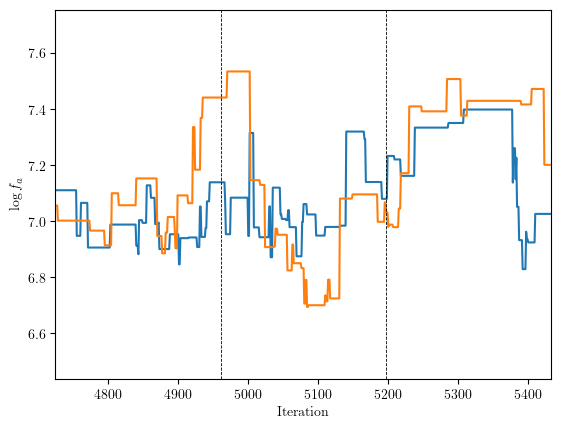

In [6]:
samples_full = sampler.get_chain()

plt.plot(samples_full[:,0, 0])
plt.plot(samples_full[:,15, 0])
plt.xlim(20*np.max(tau), 23*np.max(tau))
plt.axvline(21*np.max(tau), c='k', lw=0.6, ls='--')
plt.axvline(22*np.max(tau), c='k', lw=0.6, ls='--')
plt.xlabel('Iteration')
plt.ylabel(r'$\log f_a$')

In [7]:
samples = sampler.get_chain(flat=True, discard = int(2*np.max(tau)), thin = int(0.5*np.min(tau)))
log_lh = sampler.get_blobs(discard = int(2*np.max(tau)), thin = int(0.5*np.min(tau)))

Text(0, 0.5, '$\\chi^2$')

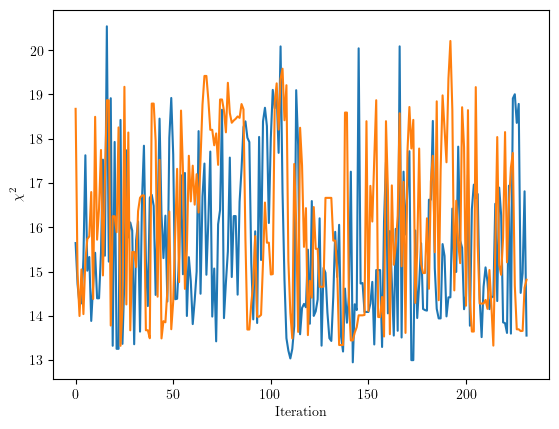

In [8]:
plt.plot(-2*log_lh[:,0])
plt.plot(-2*log_lh[:,5])
plt.xlabel('Iteration')
plt.ylabel(r'$\chi^2$')

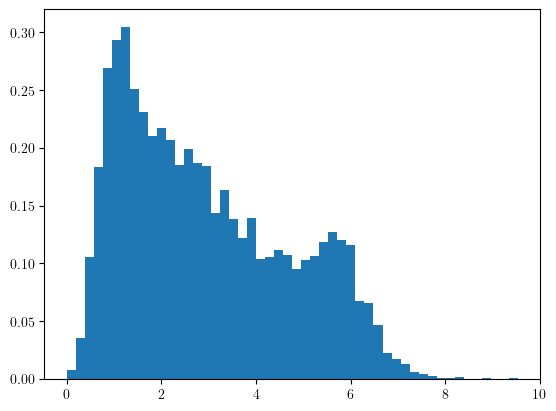

In [9]:
log_lh = sampler.get_blobs(discard = int(2*np.max(tau)), thin = int(0.5*np.min(tau)), flat=True)
_ = plt.hist(-2*log_lh+2*np.max(log_lh), bins=50, density=True)

## Histograms of the parameters

Text(0.5, 0, '$\\log_{10}(f_a)$')

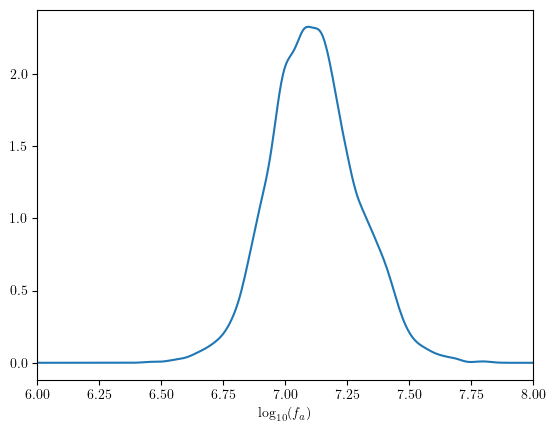

In [10]:
kde_fa = gaussian_kde(samples[:,0])
plt.plot(np.linspace(6, 8, 300), kde_fa(np.linspace(6, 8, 300)))
plt.xlim(6, 8)
plt.xlabel(r'$\log_{10}(f_a)$')

Text(0.5, 0, '$c_{q_L}^{33}/f_a$')

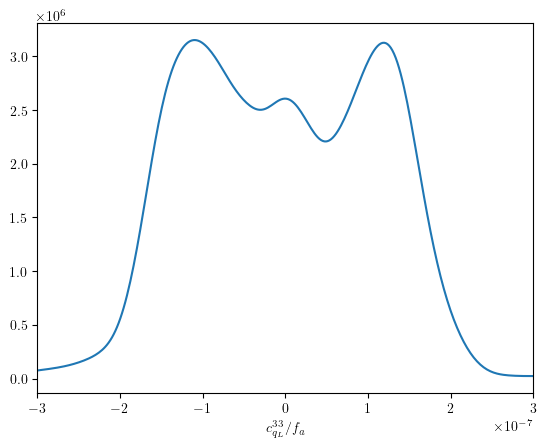

In [11]:
kde_cqL33 = gaussian_kde(samples[:,1])
plt.plot(np.linspace(-3e-7, 3e-7, 300), kde_cqL33(np.linspace(-3e-7, 3e-7, 300)))
plt.xlim(-3e-7, 3e-7)
plt.xlabel(r'$c_{q_L}^{33}/f_a$')

Text(0.5, 0, '$|c_{q_L}^{33}|/f_a$')

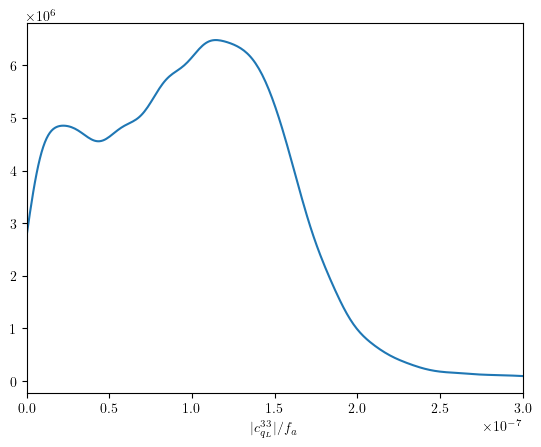

In [12]:
kde_cqL33_abs = gaussian_kde(np.abs(samples[:,1]))
plt.plot(np.linspace(0, 3e-7, 300), kde_cqL33_abs(np.linspace(0, 3e-7, 300)))
plt.xlim(0, 3e-7)
plt.xlabel(r'$|c_{q_L}^{33}|/f_a$')

Text(0.5, 0, '$|c_{u_R}|/f_a$')

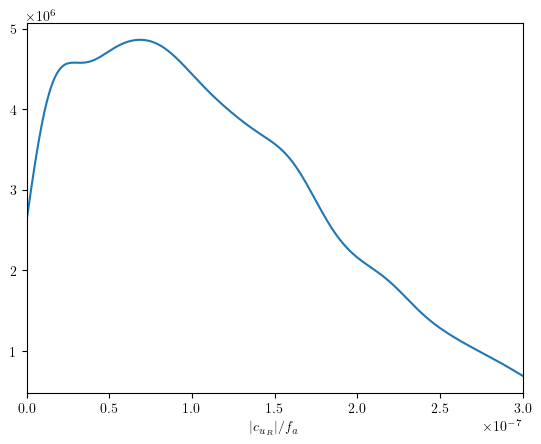

In [13]:
kde_cuR_abs = gaussian_kde(np.abs(samples[:,2]))
plt.plot(np.linspace(0, 3e-7, 300), kde_cuR_abs(np.linspace(0, 3e-7, 300)))
plt.xlim(0, 3e-7)
plt.xlabel(r'$|c_{u_R}|/f_a$')

Text(0.5, 0, '$|c_{d_R}|/f_a$')

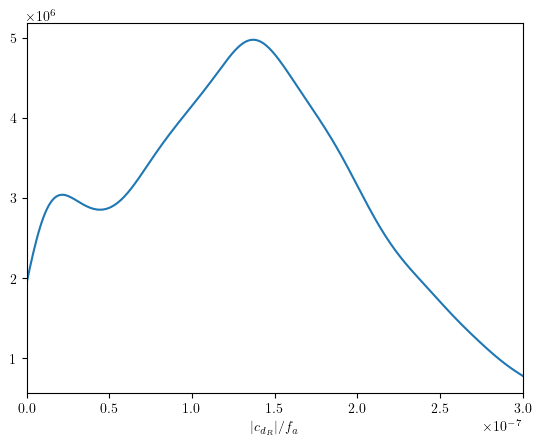

In [14]:
kde_cdR_abs = gaussian_kde(np.abs(samples[:,3]))
plt.plot(np.linspace(0, 3e-7, 300), kde_cdR_abs(np.linspace(0, 3e-7, 300)))
plt.xlim(0, 3e-7)
plt.xlabel(r'$|c_{d_R}|/f_a$')

Text(0.5, 0, '$|c_{\\ell_L}|/f_a$')

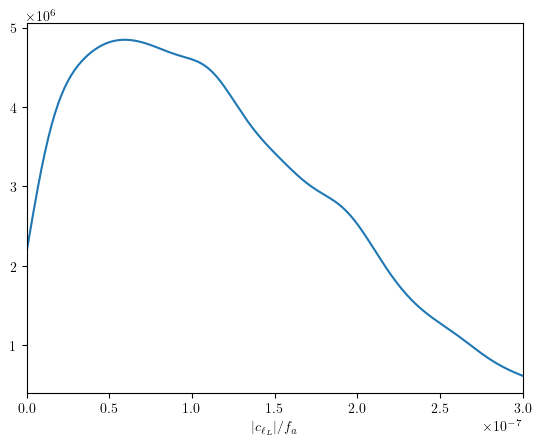

In [15]:
kde_clL33_abs = gaussian_kde(np.abs(samples[:,4]))
plt.plot(np.linspace(0, 3e-7, 300), kde_clL33_abs(np.linspace(0, 3e-7, 300)))
plt.xlim(0, 3e-7)
plt.xlabel(r'$|c_{\ell_L}|/f_a$')

Text(0.5, 0, '$|c_{e_R}|/f_a$')

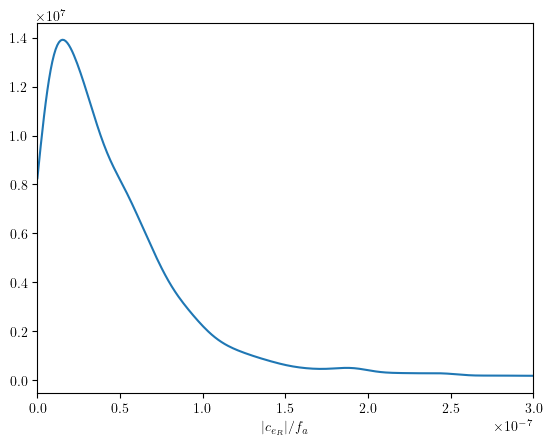

In [16]:
kde_ceR_abs = gaussian_kde(np.abs(samples[:,5]))
plt.plot(np.linspace(0, 3e-7, 300), kde_ceR_abs(np.linspace(0, 3e-7, 300)))
plt.xlim(0, 3e-7)
plt.xlabel(r'$|c_{e_R}|/f_a$')

## Expected values and corner plot

In [17]:
logfa_mean = np.mean(samples[:,0])
logfa_var = np.mean((samples[:,0] - logfa_mean)**2)
logfa_mean, np.sqrt(logfa_var)

(np.float64(7.114654577955485), np.float64(0.17618255231364627))

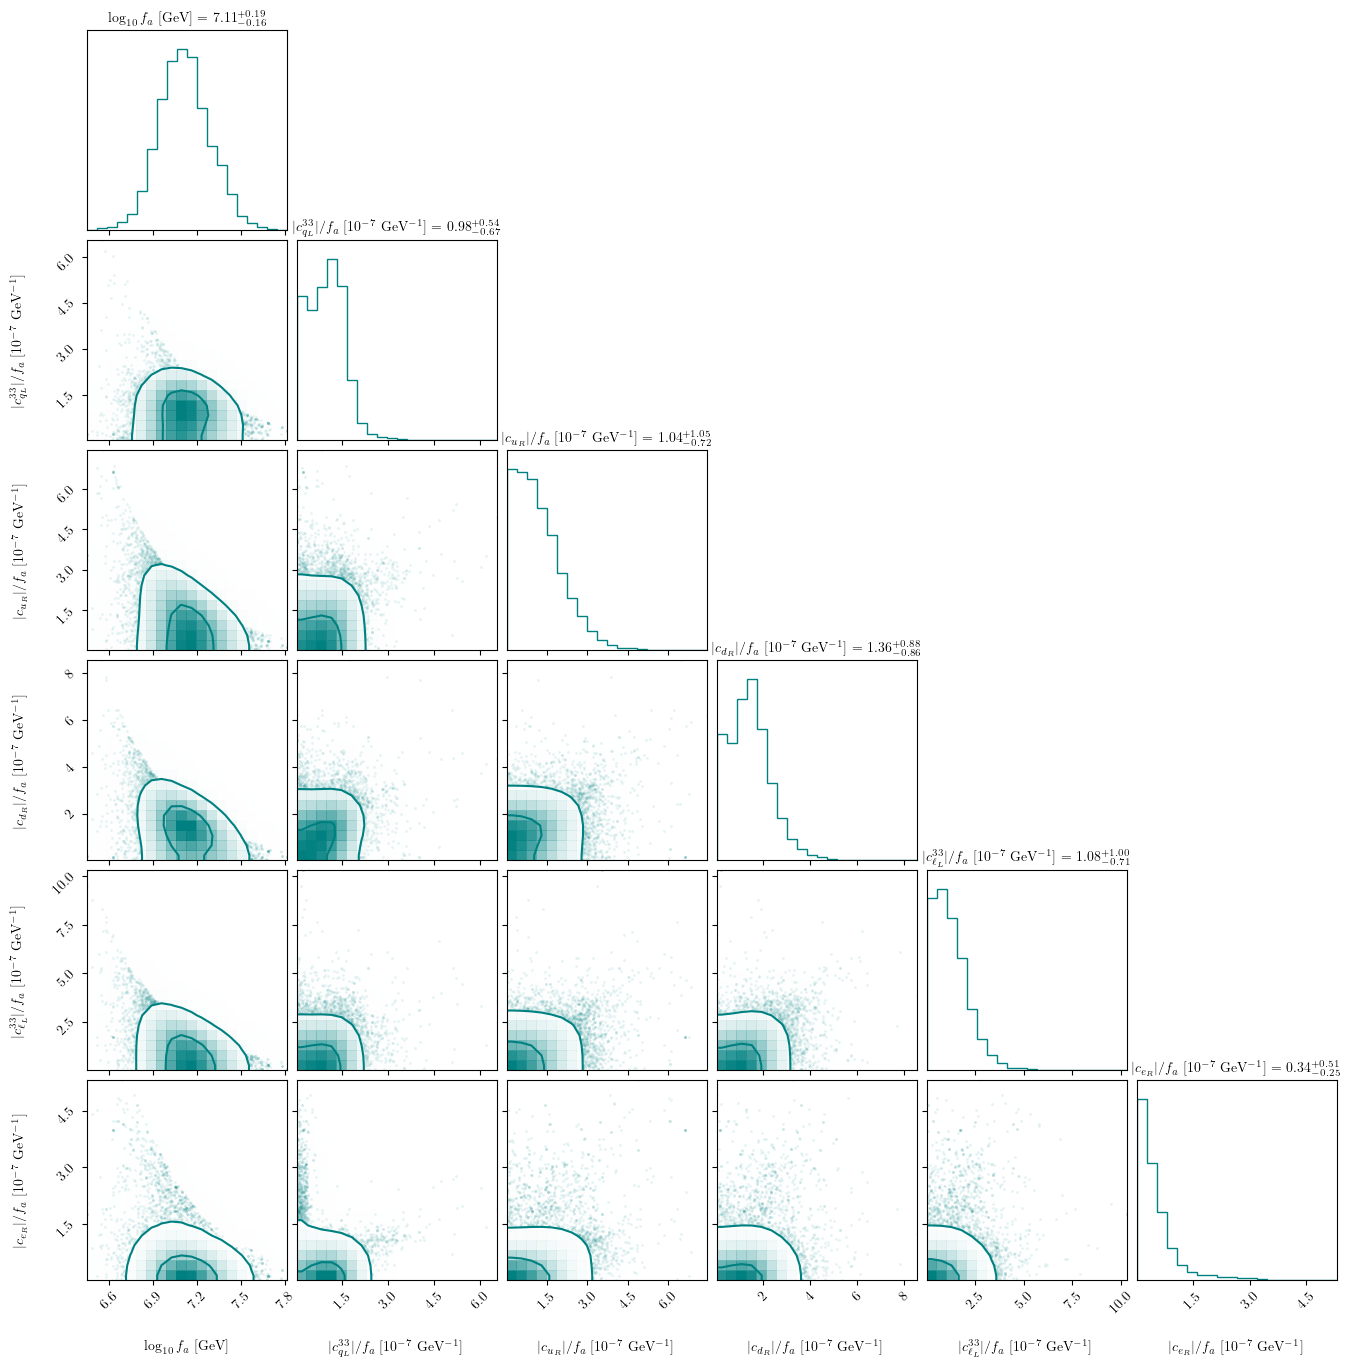

In [18]:
z0 = samples[:, 0]
z1 = np.abs((samples[:,1]))*1e7
z2 = np.abs((samples[:,2]))*1e7
z3 = np.abs((samples[:,3]))*1e7
z4 = np.abs((samples[:,4]))*1e7
z5 = np.abs((samples[:,5]))*1e7

samples_corner = np.vstack([z0, z1, z2, z3, z4, z5]).T

_ = corner.corner(
    samples_corner,
    levels=[0.393, 0.864], #1-sigma and 2-sigma for 2D gaussian
    labels=[
        r"$\log_{10} f_a$ [GeV]",
        r"$|c_{q_L}^{33}|/f_a$ [$10^{-7}$ GeV$^{-1}$]",
        r"$|c_{u_R}|/f_a$ [$10^{-7}$ GeV$^{-1}$]",
        r"$|c_{d_R}|/f_a$ [$10^{-7}$ GeV$^{-1}$]",
        r"$|c_{\ell_L}^{33}|/f_a$ [$10^{-7}$ GeV$^{-1}$]",
        r"$|c_{e_R}|/f_a$ [$10^{-7}$ GeV$^{-1}$]"
    ],
    color='teal',
    smooth=1.5,
    show_titles=True,
    #plot_datapoints=False,
    title_kwargs = {'fontsize': 10}
)